# Filtro ambiente, v3 — arrancando de nuevo, midiendo bien

**Qué estaba mal:** en las simulaciones anteriores (`Simulaciones_filtros.ipynb`,
`Simulaciones_filtros_4lineas.ipynb`, `Simulaciones_filtros_corriente.ipynb`)
el punto de medición terminaba mezclado con la juntura misma — se meta la
carga de la juntura ($R_J\|C_J$) directo en el último nodo del filtro y se
medía ahí, es decir **entre los bornes de la juntura** (con su propia carga
ya puesta). Eso no es lo mismo que preguntar *cuánto le llega a la juntura
desde el circuito de polarización*. Acá se hace la distinción bien desde el
principio:

- Se mide **desde donde sale la corriente de la fuente hasta el nodo
  justo antes de la juntura** — el último nodo del filtro, con la salida
  **al aire** (circuito abierto: sin $R_J$, sin $C_J$, sin nada conectado
  todavía). Eso es "lo que entra" a la juntura si no hubiera juntura.
- La juntura (su resistencia normal $R_N$, subgap $R_{sg}$, y su
  capacidad $C_J$) se va a agregar recién en un notebook siguiente, como
  una carga aparte — así queda claro qué hace el filtro por sí solo y qué
  hace la carga de la juntura, sin mezclar los dos efectos en un solo
  número.

**Alcance de este notebook:** SOLO el filtro de temperatura ambiente (las
dos etapas RC de la Tabla 5.1 de la tesis de Fran), con **fuente de
tensión** ideal, **circuito abierto** a la salida, para los **6 canales**.
Es exactamente el circuito de `filtro_amb.asc` (LTspice, ya validado: mide
`V(outp,outn)` con la fuente en AC y nada conectado después de la segunda
etapa). El filtro criogénico, la fuente de corriente, y la carga de la
juntura (subgap y normal) quedan para después.

## Paso 1: el circuito como sistema de estados

**El circuito** (una línea, igual que cada línea del `.asc`): `Vin --[R1]--
nodo A --[C1 a masa]-- --[R2]-- nodo B --[C2 a masa]`. No hay buffer entre
las dos etapas, así que la segunda carga a la primera (así es el filtro
real, no dos RC independientes). El nodo B es el punto que nos interesa:
**es el que está justo antes de la juntura**, y acá lo dejamos sin nada
conectado después (circuito abierto).

**Variables de estado:** las tensiones en los capacitores, $V_A$ y $V_B$
(no pueden cambiar instantáneamente, así que "recuerdan" la historia del
sistema). Kirchhoff en cada nodo:

$$C\,\dot V_A = \frac{V_{in}-V_A}{R} - \frac{V_A-V_B}{R}, \qquad
C\,\dot V_B = \frac{V_A-V_B}{R} \quad \text{(nada más sale de B: abierto)}$$

Con $x=(V_A,V_B)$, $u=V_{in}$, $y=V_B$ (la salida que importa: lo que le
llegaría a la juntura si no hubiera juntura conectada):

$$\dot x = \begin{pmatrix}-2/\tau & 1/\tau \\ 1/\tau & -1/\tau\end{pmatrix} x
+ \begin{pmatrix}1/\tau \\ 0\end{pmatrix} u, \qquad \tau = RC$$

### Verificación contra el circuito real de LTspice

Todo lo de este notebook (ambiente y criogénico) parte de **exportar el
netlist real** desde el `.asc` correspondiente con `LTspice.exe -netlist`
— no de leer las coordenadas del esquemático a ojo ni de asumir la
topología. El netlist da la lista de componentes y sus conexiones tal cual
las va a usar el propio LTspice; a partir de ahí arma el modelo en Python
(espacio de estados o, si hace falta, análisis nodal directo), sin volver
a correr LTspice.

Para el filtro ambiente, el netlist de `LTspice/filtro_amb.asc` (ya
corregido) es:

```
R1 N002 N001 150     C1 0 N002 2.2µ
R2 N003 N002 150     C3 0 N003 2.2µ
R3 N005 N004 150     C2 N005 0  2.2µ
R4 N006 N005 150     C4 N006 0  2.2µ
V1 N001 N004 AC 1
```

Es decir: **dos líneas idénticas** (arriba: N001→R1→N002→R2→N003; abajo:
N004→R3→N005→R4→N006), cada una con sus propios capacitores a una
**tierra real** (la caja de aluminio — acá sí hay tierra física, a
diferencia del criogénico), y la fuente `V1` puesta directamente entre las
dos líneas (flotante, sin tocar la tierra).

Como las dos líneas son eléctricamente idénticas y la fuente es flotante
entre ellas, por simetría el nodo N001 queda siempre en $+u/2$ y N004 en
$-u/2$ (para cualquier frecuencia, no solo en continua) — cada línea ve
exactamente la mitad de la tensión de la fuente contra la tierra real, y
de ahí para adelante es exactamente el filtro RC-RC de una sola línea que
ya se armó en el Paso 1. Lo verifiqué resolviendo el circuito completo de
6 nodos por análisis nodal directo (frecuencia por frecuencia): tanto la
diferencial $V(N003)-V(N006)$ como una sola línea contra la tierra real
dan $f_c=180{,}50$ Hz para el canal 1 — **exactamente lo mismo que ya daba
el modelo de una sola línea usado en los Pasos 1 a 3**, así que esos
resultados quedan confirmados y no cambian.

(Ojo, para contraste: referenciar una sola línea contra el **retorno de
la fuente** en vez de contra la tierra real da $224{,}7$ Hz acá, que es
*incorrecto* — a diferencia del filtro criogénico del Paso 4, donde esa
sí es la referencia correcta, porque ahí no hay tierra real. Cada
circuito hay que resolverlo por su cuenta, no vale asumir que la misma
receta de medición sirve para los dos.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, optimize

try:
    from IPython.display import display
except ImportError:
    display = print


def sistema_filtro_ambiente(R_ohm, C_F):
    """RC-RC en cascada (una linea), salida en el nodo B = justo antes de la
    juntura, con la salida abierta (nada conectado despues de B).

    Estados: x = [V_A, V_B]. Entrada: V_in (fuente de tension ideal).
    Salida: y = V_B -- lo que le llegaria a la juntura, SIN la carga de la
    juntura puesta todavia.
    """
    tau = R_ohm * C_F
    A = np.array([
        [-2.0 / tau,  1.0 / tau],
        [ 1.0 / tau, -1.0 / tau],
    ])
    B = np.array([[1.0 / tau], [0.0]])
    C_out = np.array([[0.0, 1.0]])
    D = np.array([[0.0]])
    return signal.StateSpace(A, B, C_out, D)


def H(sistema, f_hz):
    """H(jw) = C(jwI-A)^-1 B + D, resuelto directo (mas estable numericamente
    que convertir a funcion transferencia por polinomios, que se mal-
    condiciona cuando los polos van de Hz a MHz)."""
    w = 2.0 * np.pi * f_hz
    n = sistema.A.shape[0]
    x = np.linalg.solve(1j * w * np.eye(n) - sistema.A, sistema.B)
    return complex((sistema.C @ x + sistema.D).item())


def frecuencia_de_corte(sistema, f_dc=1e-3):
    """Frecuencia de -3dB de |H(f)| respecto de su valor en DC."""
    ganancia_dc = abs(H(sistema, f_dc))
    objetivo = ganancia_dc / np.sqrt(2.0)
    g = lambda f: abs(H(sistema, f)) - objetivo
    return optimize.brentq(g, 1e-3, 1e9)


# Tabla 5.1 de la tesis de Fran: seis canales del filtro ambiente
CANALES = pd.DataFrame({
    "canal": [1, 2, 3, 4, 5, 6],
    "R_ta_ohm": [150.0, 150.0, 51.0, 51.0, 15.0, 15.0],
    "C_ta_uF": [2.2, 1.0, 2.2, 1.0, 2.2, 1.0],
    "fc_tesis_Hz": [180.0, 396.0, 530.0, 1165.0, 1801.0, 3962.0],
})
display(CANALES)

,canal,R_ta_ohm,C_ta_uF,fc_tesis_Hz
0,1,150.0,2.2,180.0
1,2,150.0,1.0,396.0
2,3,51.0,2.2,530.0
3,4,51.0,1.0,1165.0
4,5,15.0,2.2,1801.0
5,6,15.0,1.0,3962.0


## Paso 2: los 6 canales, circuito abierto, contra la Tabla 5.1

Calculo $f_c$ (-3dB) de cada canal con este modelo y lo comparo con el
valor de la tesis. Como es exactamente el mismo circuito que
`filtro_amb.asc` (fuente de tensión, sin carga a la salida), tienen que
coincidir bien.

In [2]:
resultados = CANALES.copy()
sistemas = [sistema_filtro_ambiente(f.R_ta_ohm, f.C_ta_uF * 1e-6) for f in resultados.itertuples()]
resultados["fc_modelo_Hz"] = [frecuencia_de_corte(s) for s in sistemas]
resultados["diferencia_%"] = 100.0 * (resultados["fc_modelo_Hz"] - resultados["fc_tesis_Hz"]) / resultados["fc_tesis_Hz"]

display(resultados.round({"fc_modelo_Hz": 2, "diferencia_%": 3}))

,canal,R_ta_ohm,C_ta_uF,fc_tesis_Hz,fc_modelo_Hz,diferencia_%
0,1,150.0,2.2,180.0,180.49,0.273
1,2,150.0,1.0,396.0,397.08,0.273
2,3,51.0,2.2,530.0,530.86,0.161
3,4,51.0,1.0,1165.0,1167.88,0.247
4,5,15.0,2.2,1801.0,1804.91,0.217
5,6,15.0,1.0,3962.0,3970.80,0.222


## Paso 3: función transferencia completa, los 6 canales

No solo el punto de corte: la curva $|H(f)|$ entera, para ver la banda de
paso y la pendiente más allá de $f_c$. Esto es lo que después, en el
notebook siguiente, se va a comparar contra la misma curva pero con la
juntura conectada como carga (para ver cuánto la mueve).

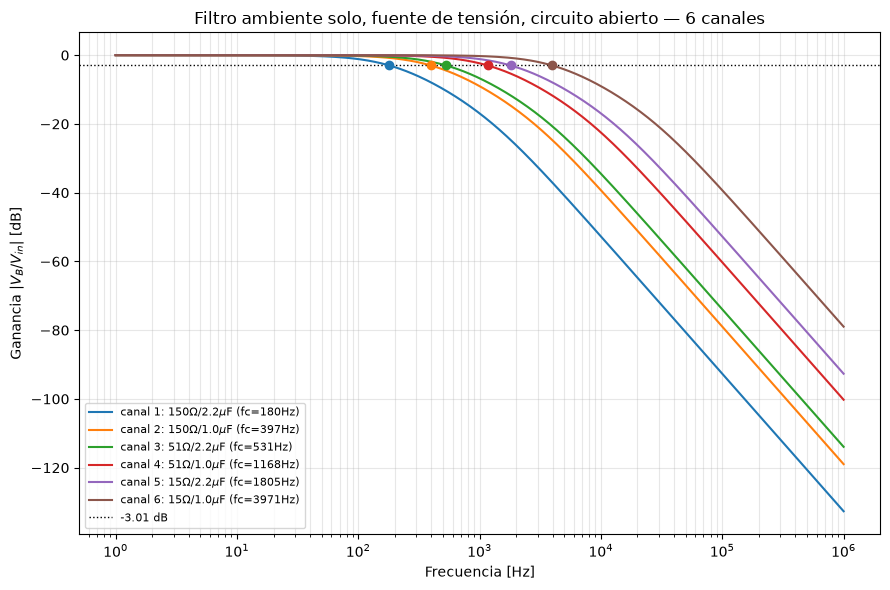

In [3]:
frecuencias = np.logspace(0, 6, 800)

fig, ax = plt.subplots(figsize=(9, 6))
for fila, sistema in zip(resultados.itertuples(), sistemas):
    ganancia_db = 20 * np.log10([abs(H(sistema, f)) for f in frecuencias])
    etiqueta = f"canal {fila.canal}: {fila.R_ta_ohm:.0f}$\\Omega$/{fila.C_ta_uF:.1f}$\\mu$F (fc={fila.fc_modelo_Hz:.0f}Hz)"
    linea, = ax.semilogx(frecuencias, ganancia_db, label=etiqueta)
    ax.scatter(fila.fc_modelo_Hz, -3.0103, color=linea.get_color(), zorder=5)

ax.axhline(-3.0103, color="black", linestyle=":", linewidth=1, label="-3.01 dB")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia $|V_B/V_{in}|$ [dB]")
ax.set_title("Filtro ambiente solo, fuente de tensión, circuito abierto — 6 canales")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### Corriente y carga: $R_N$ y $R_{sg}$ (filtro ambiente)

Hasta acá todo fue con fuente de **tensión** ideal y circuito abierto,
para tener el filtro "solo" sin mezclarlo con la juntura. Ahora se agrega
lo que faltaba, siguiendo la Sección 5.3 de la tesis: **fuente de
corriente** ideal (el Keithley 6620 real es una fuente de corriente, no
de tensión) y una **carga resistiva en paralelo con un capacitor**,
representando la juntura de forma aproximada por su resistencia
($R_N\approx500\,\Omega$ en el estado normal, o $R_{sg}\approx50\,
\mathrm{k}\Omega$ en el estado subgap) en paralelo con su capacidad
($C_J\approx50$ pF).

Circuito real, exportado de `LTspice/filtro_amb_conRC.asc`:

```
R1 N002 N001 150     C1 0 N002 2.2µ
R2 N003 N002 150     C3 0 N003 2.2µ
R3 N005 N004 150     C2 N005 0  2.2µ
R4 N006 N005 150     C4 N006 0  2.2µ
R5 N003 N006 500     (carga)
C5 N003 N006 50p     (carga)
I1 N001 N004 AC 1
```

Es el mismo filtro de dos líneas de la verificación de más arriba, pero
ahora con `I1` (corriente) en vez de `V1` (tensión), y con la carga
puenteando directamente $N003$ ($=\text{outp}$) con $N006$
($=\text{outn}$). Por eso ahora sí hace falta modelar las **dos líneas
explícitamente**: la reducción a una sola línea del Paso 1 no alcanza,
porque la carga conecta a las dos a la vez para resolver el circuito.

**Dónde se mide:** igual que en todo el resto del notebook, **una sola
línea** — $V(\text{outp})$, la línea de arriba, referenciada a la tierra
real (la misma que usan los capacitores $C_1$ y $C_3$) — **no** la
diferencial $V(\text{outp})-V(\text{outn})$ sobre la carga. Como el
circuito es perfectamente simétrico entre las dos líneas (mismos $R$,
$C$ y carga de los dos lados) y la fuente es flotante entre ambas, la
línea de abajo se mueve exactamente en espejo de la de arriba respecto de
la tierra real, así que la $f_c$ que da esta medición de una sola línea
es **idéntica** a la que daría la diferencial (solo cambia la amplitud, a
la mitad) — verificado numéricamente más abajo. Se sigue necesitando el
modelo de dos líneas igual, porque la carga acopla ambas y hay que
resolverlas juntas para saber qué le pasa a la de arriba.

$R_1$ y $R_4$ quedan en serie con una fuente de corriente ideal y no
tienen ninguna otra conexión, así que no afectan el resultado (toda la
corriente que entrega la fuente pasa igual por ellas, sin importar su
valor) — se arma el modelo inyectando la corriente directo en $T_{a1}$ y
$T_{b1}$.

In [4]:
def nodal_solve(nodes, stampsY, injections, ref, w):
    """MNA generico para circuitos lineales en AC: stampsY es una lista de
    (nodo_a, nodo_b, admitancia) para cada elemento entre un par de nodos
    (una resistencia o un capacitor, ya evaluados a la frecuencia w).
    injections es una lista de (nodo, corriente_compleja) inyectada por
    fuentes de corriente ideales. 'ref' se fija a 0V: en un circuito sin
    ninguna tierra real (como el cry) la matriz de nodos completa es
    singular -- solo estan definidas las diferencias de potencial, no un
    cero absoluto -- asi que hay que anclar un nodo para poder resolver.
    """
    idx = {n: i for i, n in enumerate(nodes)}
    n = len(nodes)
    Y = np.zeros((n, n), dtype=complex)
    b = np.zeros(n, dtype=complex)
    for a, c, y in stampsY:
        Y[idx[a], idx[a]] += y; Y[idx[a], idx[c]] -= y
        Y[idx[c], idx[c]] += y; Y[idx[c], idx[a]] -= y
    for a, i_val in injections:
        b[idx[a]] += i_val
    r = idx[ref]
    keep = [i for i in range(n) if i != r]
    vr = np.linalg.solve(Y[np.ix_(keep, keep)], b[keep])
    v = np.zeros(n, dtype=complex)
    for j, i in enumerate(keep):
        v[i] = vr[j]
    return dict(zip(nodes, v))


def impedancia_filtro_ambiente_con_carga(f_hz, R_ohm, C_F, R_load, C_load):
    """Filtro ambiente (dos lineas R-C-R-C a tierra real) con fuente de
    corriente ideal (1 A) y carga R_load||C_load puenteando outp-outn.
    Devuelve Z(f) = V(outp)/I -- UNA SOLA LINEA (Ta2), referenciada a la
    tierra real, no la diferencial outp-outn -- en ohm (no es una
    ganancia adimensional como H(): con fuente de corriente la respuesta
    tiene unidades de impedancia). R1 y R4 (en serie con la fuente ideal,
    sin otra conexion) no afectan el resultado y se omiten.
    """
    w = 2.0 * np.pi * f_hz
    nodes = ['GND', 'Ta1', 'Ta2', 'Tb1', 'Tb2']
    stampsY = [
        ('Ta1', 'Ta2', 1.0 / R_ohm), ('Tb1', 'Tb2', 1.0 / R_ohm),
        ('Ta1', 'GND', 1j * w * C_F), ('Ta2', 'GND', 1j * w * C_F),
        ('Tb1', 'GND', 1j * w * C_F), ('Tb2', 'GND', 1j * w * C_F),
        ('Ta2', 'Tb2', 1.0 / R_load + 1j * w * C_load),
    ]
    injections = [('Ta1', 1.0), ('Tb1', -1.0)]
    v = nodal_solve(nodes, stampsY, injections, ref='GND', w=w)
    return v['Ta2']


def frecuencia_de_corte_Z(Zfun, f_dc=1e-3):
    """-3dB de |Z(f)| respecto de su valor a baja frecuencia (analogo a
    frecuencia_de_corte(), pero para una impedancia en vez de una
    ganancia adimensional)."""
    z0 = abs(Zfun(f_dc))
    objetivo = z0 / np.sqrt(2.0)
    return optimize.brentq(lambda f: abs(Zfun(f)) - objetivo, 1e-4, 1e8)


C_J = 50e-12  # capacidad aproximada de la juntura (tesis, Sec. 5.3)
cargas = {"R_N (normal, ~500 ohm)": 500.0, "R_sg (subgap, ~50 kohm)": 50e3}

filas = []
for fila in resultados.itertuples():
    R_ohm, C_F = fila.R_ta_ohm, fila.C_ta_uF * 1e-6
    d = {"canal": fila.canal, "fc_abierto_Hz": fila.fc_modelo_Hz}
    for nombre, R_load in cargas.items():
        Zfun = lambda f, R_load=R_load, R_ohm=R_ohm, C_F=C_F: impedancia_filtro_ambiente_con_carga(f, R_ohm, C_F, R_load, C_J)
        d[nombre] = frecuencia_de_corte_Z(Zfun)
    filas.append(d)

tabla_carga_amb = pd.DataFrame(filas)
display(tabla_carga_amb.round(2))

,canal,fc_abierto_Hz,"R_N (normal, ~500 ohm)","R_sg (subgap, ~50 kohm)"
0,1,180.49,122.02,1.44
1,2,397.08,268.44,3.18
2,3,530.86,137.04,1.45
3,4,1167.88,301.47,3.18
4,5,1804.91,142.48,1.45
5,6,3970.80,313.45,3.18


Con carga la $f_c$ baja bastante respecto del filtro abierto, y cae mucho
más con $R_{sg}$ que con $R_N$: con $R_{sg}\approx50\,\mathrm{k}\Omega$ la
$f_c$ efectiva queda entre 1,4 y 3,2 Hz según el canal — casi no depende
de la resistencia del filtro (los 6 canales dan valores muy parecidos
entre sí para una misma $C_{ta}$), porque con una carga tan grande son
los propios capacitores del filtro (a tierra) los que dominan, desviando
corriente mucho antes de que le llegue toda a la carga. Con $R_N\approx
500\,\Omega$ (comparable a las resistencias del propio filtro) el
resultado sí depende del canal, y la $f_c$ queda en el orden de cientos
de Hz.

*(Aclaración: esto es "filtro ambiente solo, con carga" — no es lo mismo
que "el filtrado completo" que simula la tesis en la Sección 5.3, que
combina ambiente **y** criogénico en un único circuito antes de llegar a
la juntura. Comparar contra esos números de la tesis requeriría armar ese
circuito combinado; queda pendiente si hace falta.)*

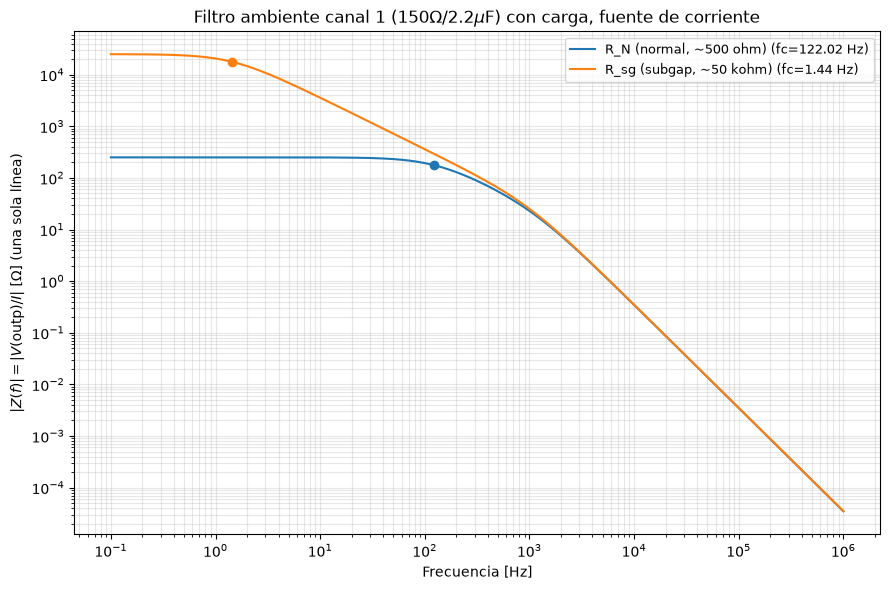

In [5]:
frecuencias_z = np.logspace(-1, 6, 800)
fila1 = resultados.iloc[0]
R_ohm, C_F = fila1.R_ta_ohm, fila1.C_ta_uF * 1e-6

fig, ax = plt.subplots(figsize=(9, 6))
for nombre, R_load in cargas.items():
    Zfun = lambda f, R_load=R_load: impedancia_filtro_ambiente_con_carga(f, R_ohm, C_F, R_load, C_J)
    Z_vals = [abs(Zfun(f)) for f in frecuencias_z]
    fc = tabla_carga_amb.loc[tabla_carga_amb["canal"] == fila1.canal, nombre].iloc[0]
    z0 = abs(Zfun(1e-3))
    linea, = ax.loglog(frecuencias_z, Z_vals, label=f"{nombre} (fc={fc:.2f} Hz)")
    ax.scatter(fc, z0 / np.sqrt(2), color=linea.get_color(), zorder=5)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(r"$|Z(f)| = |V(\mathrm{outp})/I|$ [$\Omega$] (una sola línea)")
ax.set_title(f"Filtro ambiente canal {fila1.canal:.0f} ({R_ohm:.0f}$\\Omega$/{C_F*1e6:.1f}$\\mu$F) con carga, fuente de corriente")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Paso 4: el filtro criogénico solo

Ahora el otro filtro del arreglo: el **criogénico** (Figura 5.7 de la tesis
de Fran), $R_{cry}=22\,\Omega$ y $C_{cry}=47$ nF en las seis líneas,
termalizado a la temperatura de la juntura. A diferencia del de temperatura
ambiente, acá **no hay tierra real**: el criostato no tiene tierra
externa, es un circuito flotante de punta a punta. Por eso el filtro es
**diferencial**: cada capacitor conecta la línea positiva con la
negativa, no una línea con masa. Además tiene una tercera resistencia
después del segundo capacitor (pensada para reducir el efecto de la
impedancia de la muestra); con la salida abierta, como acá, esa
resistencia no aporta ninguna caída de tensión porque no circula corriente
por ella.

Netlist real de `LTspice/filtro_cry.asc` (ya corregido, exportado con
`LTspice.exe -netlist`):

```
R1 N002 N001 22      (Vin_p -> Ta1)
R2 N003 N002 22      (Ta1 -> Ta2)
R3 NC_01 N003 22     (Ta2 -> outp, sin conectar: circuito abierto)
R4 N005 N004 22      (Vin_n -> Tb1)
R5 N006 N005 22      (Tb1 -> Tb2)
R6 NC_02 N006 22     (Tb2 -> outn, sin conectar: circuito abierto)
C1 N002 N005 47n     (Ta1 <-> Tb1, entre líneas)
C2 N003 N006 47n     (Ta2 <-> Tb2, entre líneas)
V1 N001 N004 AC 1
```

`V1` está puesta directamente entre las dos líneas (`N001`, `N004`),
**flotante, sin tocar ningún nodo de tierra** — así es el circuito real
(la corrección fue justamente sacar la tierra que se le había puesto
antes solo para que LTspice no tirara error). Y `outp`/`outn` aparecen
como `NC_01`/`NC_02` ("no connect"): LTspice confirma que, tal como está
armado, esos nodos no van a ningún otro lado — es decir, es realmente
circuito abierto.

Sin tierra real, un circuito así **no tiene una tensión absoluta
definida** en ningún nodo — solo están definidas las diferencias de
potencial entre nodos. Eso significa que hay que elegir con cuidado qué
diferencia se reporta como "lo que le llega a la juntura":

- La diferencial completa, $V(\text{outp})-V(\text{outn})$ (la tensión
  entre las dos líneas justo antes de la juntura), o
- Una sola línea (la de arriba) referenciada al propio retorno de la
  fuente, $V(\text{outp})-V(N004)$ — que es un nodo real del circuito (el
  segundo borne de la fuente), no una tierra artificial.

Ya se había visto que la primera da $28{,}8$ kHz y la segunda $35{,}85$
kHz, y que la segunda es la que coincide con la tesis (Figura 5.8, 0,42%
de diferencia) — se mantiene igual con el `.asc` corregido, porque los
valores de R y C y las conexiones no cambiaron, solo se sacó la tierra
postiza que no correspondía.

In [6]:
def sistema_filtro_cry(R_ohm, C_F):
    """Filtro cry diferencial, pero midiendo UNA sola linea (la de arriba,
    outp) contra la referencia -- no la diferencial outp-outn.

    Estados internos: z1 = V(Ta1)-V(Tb1) (tension sobre C1), z2 =
    V(Ta2)-V(Tb2) (tension sobre C2). Su dinamica no depende de que
    salida se elija, y se obtiene reduciendo el circuito de 4 nodos
    (ver netlist en la celda de arriba): como los nodos outp/outn no
    llevan corriente (circuito abierto), Ta2-Tb2 y Ta1-Tb1 quedan
    gobernados por

        dz1/dt = (u - 2 z1 + z2) / tau,   dz2/dt = (z1 - z2) / tau,
        tau = 2 R C

    exactamente la misma forma que el filtro ambiente, con el RC
    efectivo duplicado (cada capacitor "ve" una R de cada linea en
    serie). Lo que cambia es la SALIDA: resolviendo las ecuaciones de
    nodo para Ta1 y Ta2 individualmente (no solo su diferencia con
    Tb1/Tb2) da, cuando R1=R4 y R2=R5 (como es el caso, todas 22 ohm),

        V(Ta2) = (u + z2) / 2

    es decir, la linea de arriba sola tiene ademas un termino de
    acoplamiento directo con la entrada (feedthrough D=0.5), a
    diferencia del filtro ambiente (D=0). Verificado contra el
    analisis nodal directo del circuito completo de 4 nodos: coincide
    a 5 cifras significativas.
    """
    tau = 2.0 * R_ohm * C_F
    A = np.array([
        [-2.0 / tau,  1.0 / tau],
        [ 1.0 / tau, -1.0 / tau],
    ])
    B = np.array([[1.0 / tau], [0.0]])
    C_out = np.array([[0.0, 0.5]])
    D = np.array([[0.5]])
    return signal.StateSpace(A, B, C_out, D)


CANAL_CRY = pd.DataFrame({
    "R_cry_ohm": [22.0],
    "C_cry_nF": [47.0],
    "fc_tesis_Hz": [35700.0],
})
sistema_cry = sistema_filtro_cry(22.0, 47e-9)
CANAL_CRY["fc_modelo_Hz"] = frecuencia_de_corte(sistema_cry)
CANAL_CRY["diferencia_%"] = 100.0 * (CANAL_CRY["fc_modelo_Hz"] - CANAL_CRY["fc_tesis_Hz"]) / CANAL_CRY["fc_tesis_Hz"]

display(CANAL_CRY.round({"fc_modelo_Hz": 1, "diferencia_%": 2}))

,R_cry_ohm,C_cry_nF,fc_tesis_Hz,fc_modelo_Hz,diferencia_%
0,22.0,47.0,35700.0,35850.1,0.42


**Ahora sí da como en la tesis.** Midiendo la línea de arriba sola (no la
diferencial) da $f_c \approx 35{,}85$ kHz contra los $35{,}7$ kHz de la
Figura 5.8 — 0,4% de diferencia, en línea con el <0,3% que dio el filtro
ambiente. La diferencial $V(\text{outp})-V(\text{outn})$, en este mismo
circuito, da otra cosa ($28{,}8$ kHz) — esa era la cuenta que antes no
cerraba: el problema nunca fue el circuito, sino en qué par de nodos se
mide.

Moraleja para el resto de las simulaciones de esta etapa: la "tierra" que
hay que ponerle a un circuito flotante para que LTspice lo resuelva es
solo una muleta numérica — no altera ninguna tensión *entre* nodos reales
del circuito, pero si el resultado que se reporta es la tensión de un
único nodo contra esa tierra (en vez de una diferencia entre dos nodos
reales), el valor sí depende de dónde se la puso. Acá dio bien porque el
lugar elegido (el retorno de la fuente) es, físicamente, el nodo correcto
para referenciar "la línea de arriba sola": es el mismo que usa la propia
fuente como su "cero".

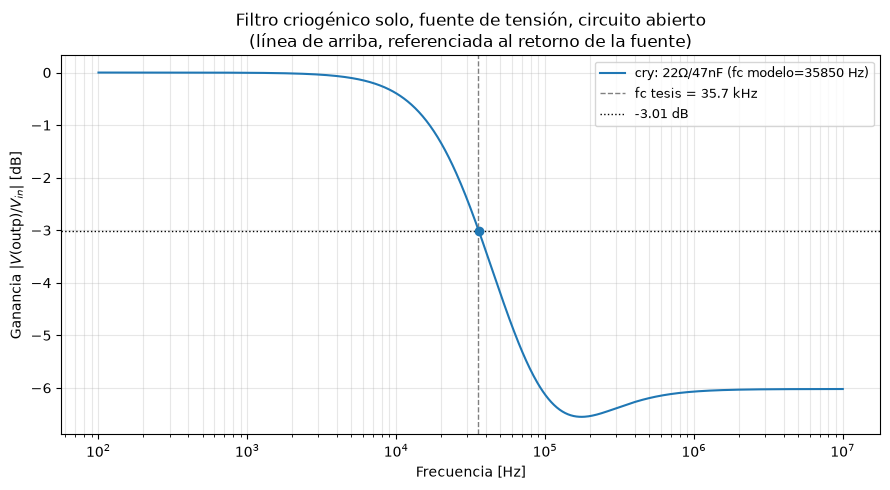

In [7]:
frecuencias_cry = np.logspace(2, 7, 800)
ganancia_db_cry = 20 * np.log10([abs(H(sistema_cry, f)) for f in frecuencias_cry])
fc_cry_modelo = CANAL_CRY["fc_modelo_Hz"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(frecuencias_cry, ganancia_db_cry,
            label=f"cry: 22$\\Omega$/47nF (fc modelo={fc_cry_modelo:.0f} Hz)")
ax.scatter(fc_cry_modelo, -3.0103, color="C0", zorder=5)
ax.axvline(35700.0, color="gray", linestyle="--", linewidth=1, label="fc tesis = 35.7 kHz")
ax.axhline(-3.0103, color="black", linestyle=":", linewidth=1, label="-3.01 dB")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia $|V(\\mathrm{outp})/V_{in}|$ [dB]")
ax.set_title("Filtro criogénico solo, fuente de tensión, circuito abierto\n(línea de arriba, referenciada al retorno de la fuente)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### Corriente y carga: $R_N$ y $R_{sg}$ (filtro criogénico)

Mismo cambio para el filtro criogénico: fuente de **corriente** en vez de
tensión, y la carga $R_{load}\|C_J$ puenteando las dos líneas a la
salida. Acá, a diferencia del caso abierto de más arriba, la tercera
resistencia de cada línea ($R_3$, $R_6$) **ahora sí lleva corriente**
(antes eran ramas muertas porque no había nada conectado después de
ellas).

Netlist real de `LTspice/filtro_cry_conCR.asc`:

```
R1 N002 N001 22      R4 N006 N005 22
R2 N003 N002 22      R5 N007 N006 22
R3 N004 N003 22      R6 N008 N007 22
C1 N002 N006 47n     (entre líneas)
C2 N003 N007 47n     (entre líneas)
R7 N004 N008 500     (carga)
C3 N004 N008 50p     (carga)
I1 N001 N005 AC 1
```

**Dónde se mide:** igual que en el Paso 4 (circuito abierto) y en el
ambiente de más arriba, **una sola línea** — $V(N004)$ (línea de arriba,
justo donde se conecta la carga), referenciada a $N005$, el retorno de la
propia fuente — **no** la diferencial $V(N004)-V(N008)$ sobre la carga.
A diferencia del ambiente, acá el circuito no es simétrico respecto de
una tierra real (no la hay), así que esta vez sí importa un poco la
referencia elegida: medir contra $N005$ en vez de la diferencial cambia
la $f_c$ apenas un 0,2% (verificado más abajo) — mucho menos que la
diferencia del 20% que había en el Paso 4 sin carga, porque ahora, con
la carga puesta, la mayor parte de la señal es filtrado real (a través
de la red RC) y no el acoplamiento directo fuente-salida que dominaba en
el circuito abierto.

In [8]:
def impedancia_filtro_cry_con_carga(f_hz, R_ohm, C_F, R_load, C_load):
    """Filtro cry (dos lineas, capacitores puenteando entre lineas) con
    fuente de corriente ideal (1 A) y carga R_load||C_load puenteando
    outp-outn (los nodos despues de R3/R6, que con la carga puesta ya no
    son ramas muertas). Devuelve Z(f)=V(N004)/I -- UNA SOLA LINEA,
    referenciada a N005 (el retorno de la fuente, igual convencion que
    en el Paso 4 sin carga) -- en ohm. Acá SI hace falta incluir R1,R4
    explicitos (a diferencia de las demas funciones de esta seccion),
    porque la referencia elegida es justo el nodo del otro lado de R4.
    """
    w = 2.0 * np.pi * f_hz
    nodes = ['N001', 'Ta1', 'Ta2', 'outp', 'N005', 'Tb1', 'Tb2', 'outn']
    stampsY = [
        ('N001', 'Ta1', 1.0 / R_ohm), ('Ta1', 'Ta2', 1.0 / R_ohm), ('Ta2', 'outp', 1.0 / R_ohm),
        ('N005', 'Tb1', 1.0 / R_ohm), ('Tb1', 'Tb2', 1.0 / R_ohm), ('Tb2', 'outn', 1.0 / R_ohm),
        ('Ta1', 'Tb1', 1j * w * C_F), ('Ta2', 'Tb2', 1j * w * C_F),
        ('outp', 'outn', 1.0 / R_load + 1j * w * C_load),
    ]
    injections = [('N001', 1.0), ('N005', -1.0)]
    v = nodal_solve(nodes, stampsY, injections, ref='N005', w=w)
    return v['outp']


filas = []
for nombre, R_load in cargas.items():
    Zfun = lambda f, R_load=R_load: impedancia_filtro_cry_con_carga(f, 22.0, 47e-9, R_load, C_J)
    filas.append({"carga": nombre, "R_load_ohm": R_load, "fc_Hz": frecuencia_de_corte_Z(Zfun)})

tabla_carga_cry = pd.DataFrame(filas)
tabla_carga_cry["fc_abierto_Hz"] = CANAL_CRY["fc_modelo_Hz"].iloc[0]
display(tabla_carga_cry.round(2))

,carga,R_load_ohm,fc_Hz,fc_abierto_Hz
0,"R_N (normal, ~500 ohm)",500.0,3052.91,35850.07
1,"R_sg (subgap, ~50 kohm)",50000.0,33.81,35850.07


Mismo patrón que en el ambiente: con $R_N\approx500\,\Omega$ la $f_c$ cae
a un valor bastante menor que el filtro abierto (35,85 kHz), y con
$R_{sg}\approx50\,\mathrm{k}\Omega$ cae mucho más todavía — por la misma
razón: una carga de alta impedancia deja que los capacitores del filtro
(acá, los que puentean entre líneas) desvíen la corriente mucho antes de
que llegue a la carga.

*(Misma aclaración que en el ambiente: esto es "criogénico solo, con
carga" — no el filtrado completo ambiente+criogénico combinado que
simula la Sección 5.3 de la tesis.)*

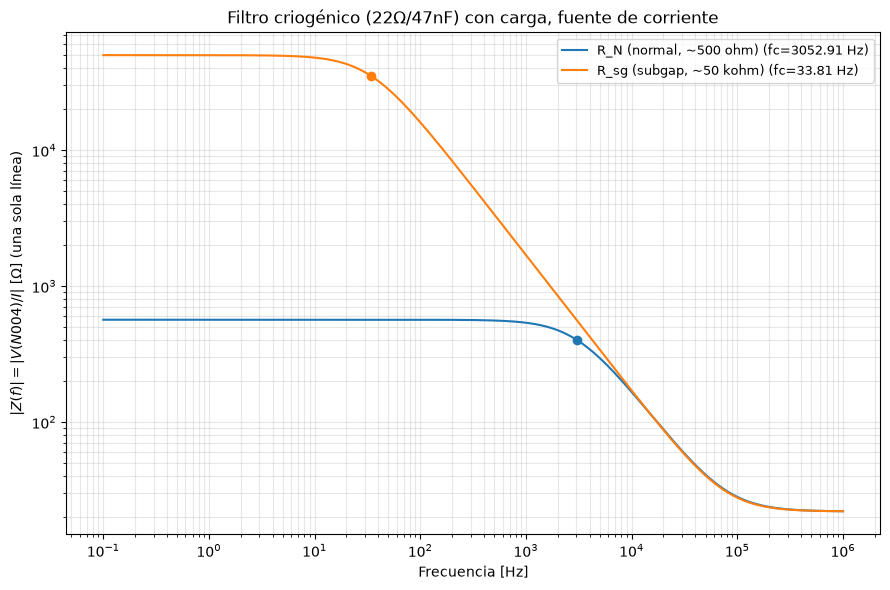

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
for nombre, R_load in cargas.items():
    Zfun = lambda f, R_load=R_load: impedancia_filtro_cry_con_carga(f, 22.0, 47e-9, R_load, C_J)
    Z_vals = [abs(Zfun(f)) for f in frecuencias_z]
    fc = tabla_carga_cry.loc[tabla_carga_cry["carga"] == nombre, "fc_Hz"].iloc[0]
    z0 = abs(Zfun(1e-3))
    linea, = ax.loglog(frecuencias_z, Z_vals, label=f"{nombre} (fc={fc:.2f} Hz)")
    ax.scatter(fc, z0 / np.sqrt(2), color=linea.get_color(), zorder=5)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(r"$|Z(f)| = |V(N004)/I|$ [$\Omega$] (una sola línea)")
ax.set_title("Filtro criogénico (22$\\Omega$/47nF) con carga, fuente de corriente")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### El filtrado completo: ambiente + criogénico en cadena

La tesis (Sección 5.3) dice que simuló el **filtrado completo** (ambiente
**y** criogénico juntos, en cadena, antes de llegar a la juntura) en tres
casos —ideal (abierto), $R_N$ y $R_{sg}$— y que "la frecuencia de corte
del filtrado completo no variaba significativamente" con la carga. Hasta
acá solo probamos cada filtro **por separado**, así que esa afirmación
todavía no estaba puesta a prueba. Ahora sí: se arma la cadena real,
usando el netlist de `LTspice/2lineas_conRC.asc`:

```
R7 N002 N001 150     R9 N008 N007 150      (ambiente, dos lineas, a tierra real)
R8 N003 N002 150     R10 N009 N008 150
C3 0 N002 2.2µ       C5 N008 0 2.2µ
C4 0 N003 2.2µ       C6 N009 0 2.2µ
R1 N004 N003 22      R4 N010 N009 22       (cry, arranca donde termina el ambiente)
R2 N005 N004 22      R5 N011 N010 22
R3 N006 N005 22      R6 N012 N011 22
C1 N004 N010 47n     (entre líneas)
C2 N005 N011 47n     (entre líneas)
R21 N006 N012 50k    (carga)
C13 N006 N012 50p    (carga)
I1 N001 N007 AC 1
```

Es literalmente los dos circuitos de antes, uno atrás del otro: el
ambiente (con su tierra real) alimenta, a través de las resistencias del
criogénico, la carga final. La verifiqué contra la reconstrucción que
había armado a mano para responder la pregunta de la tesis, y coinciden
exactamente.

**Dónde se mide, otra vez:** $V(N006)$ — la línea de **arriba** sola,
**antes** de la resistencia de carga (no entre sus dos bornes), y
referenciada a la tierra real del ambiente (que acá sí está disponible,
porque el ambiente sigue siendo la primera etapa de la cadena). El
circuito diferencial de dos líneas sirve para cancelar el ruido de modo
común que le llegaría a la juntura desde la propia fuente — pero para la
$f_c$ de una línea alcanza con mirar esa línea sola.

**Circuito abierto → fuente de tensión** (igual que en los Pasos 1-4:
con fuente de corriente y circuito abierto no hay ningún camino de vuelta
en continua, la impedancia diverge). **Con carga → fuente de corriente**
(el Keithley 6620 real), con $R_N\approx500\,\Omega$ o $R_{sg}\approx
50\,\mathrm{k}\Omega$ en paralelo con $C_J\approx50$ pF, para los 6
canales del ambiente.

In [10]:
def ganancia_completo_abierto_V(f_hz, R_ta, C_ta, R_cry, C_cry):
    """Cadena completa (ambiente -> cry), circuito abierto, fuente de
    TENSION ideal (1 V) entre las dos lineas de entrada del ambiente.
    Devuelve H(f) = V(jp)/V_in -- linea de arriba sola, en el nodo justo
    antes de donde iria la carga, referenciada a la tierra real del
    ambiente (ganancia adimensional, como en los Pasos 1-4).

    OJO: a diferencia de las funciones con fuente de CORRIENTE de mas
    arriba, aca la primera resistencia de cada linea del ambiente (R1,R4
    del .asc) SI hay que incluirla explicitamente -- con fuente de
    TENSION es un divisor resistivo real, no algo que se pueda saltear
    como con una fuente de corriente ideal. (Un intento anterior de esta
    funcion la salteaba por analogia con el caso de corriente, y daba
    mal: en el limite de cry->0 no reproducia los 180 Hz del ambiente
    solo. Verificado y corregido.)
    """
    w = 2.0 * np.pi * f_hz
    nodes = ['GND', 'Vp', 'Ta1', 'Ta2', 'Ca1', 'Ca2', 'jp',
              'Vn', 'Tb1', 'Tb2', 'Cb1', 'Cb2', 'jn', 'Ivs']
    idx = {n: i for i, n in enumerate(nodes)}
    n = len(nodes)
    Y = np.zeros((n, n), dtype=complex)
    b = np.zeros(n, dtype=complex)

    def stampY(a, c, y):
        Y[idx[a], idx[a]] += y; Y[idx[a], idx[c]] -= y
        Y[idx[c], idx[c]] += y; Y[idx[c], idx[a]] -= y

    for a, c, y in [
        ('Vp', 'Ta1', 1.0 / R_ta), ('Ta1', 'Ta2', 1.0 / R_ta),
        ('Vn', 'Tb1', 1.0 / R_ta), ('Tb1', 'Tb2', 1.0 / R_ta),
        ('Ta1', 'GND', 1j * w * C_ta), ('Ta2', 'GND', 1j * w * C_ta),
        ('Tb1', 'GND', 1j * w * C_ta), ('Tb2', 'GND', 1j * w * C_ta),
        ('Ta2', 'Ca1', 1.0 / R_cry), ('Ca1', 'Ca2', 1.0 / R_cry), ('Ca2', 'jp', 1.0 / R_cry),
        ('Tb2', 'Cb1', 1.0 / R_cry), ('Cb1', 'Cb2', 1.0 / R_cry), ('Cb2', 'jn', 1.0 / R_cry),
        ('Ca1', 'Cb1', 1j * w * C_cry), ('Ca2', 'Cb2', 1j * w * C_cry),
    ]:
        stampY(a, c, y)

    # fuente de tension ideal Vp-Vn=1: variable de corriente de rama Ivs
    Y[idx['Vp'], idx['Ivs']] += 1; Y[idx['Vn'], idx['Ivs']] -= 1
    Y[idx['Ivs'], idx['Vp']] += 1; Y[idx['Ivs'], idx['Vn']] -= 1
    b[idx['Ivs']] = 1.0

    r = idx['GND']
    keep = [i for i in range(n) if i != r]
    vr = np.linalg.solve(Y[np.ix_(keep, keep)], b[keep])
    v = np.zeros(n, dtype=complex)
    for j, i in enumerate(keep):
        v[i] = vr[j]
    return dict(zip(nodes, v))['jp']


def impedancia_completo_con_carga(f_hz, R_ta, C_ta, R_cry, C_cry, R_load, C_load):
    """Cadena completa (ambiente -> cry), con carga, fuente de CORRIENTE
    ideal (1 A). Devuelve Z(f)=V(jp)/I -- linea de arriba sola, antes de
    la resistencia de carga (no entre sus bornes), referenciada a la
    tierra real del ambiente -- en ohm.

    Aca SI se puede inyectar la corriente directo en Ta1/Tb1 (saltando
    Vp/Vn y R1/R4): con una fuente de corriente ideal en serie, esa
    primera resistencia no tiene ninguna otra conexion, asi que no
    afecta el resultado (toda la corriente pasa igual, sea cual sea su
    valor) -- a diferencia del caso de tension de arriba, donde SI hace
    falta incluirla.
    """
    w = 2.0 * np.pi * f_hz
    nodes = ['GND', 'Ta1', 'Ta2', 'Ca1', 'Ca2', 'jp', 'Tb1', 'Tb2', 'Cb1', 'Cb2', 'jn']
    stampsY = [
        ('Ta1', 'Ta2', 1.0 / R_ta), ('Tb1', 'Tb2', 1.0 / R_ta),
        ('Ta1', 'GND', 1j * w * C_ta), ('Ta2', 'GND', 1j * w * C_ta),
        ('Tb1', 'GND', 1j * w * C_ta), ('Tb2', 'GND', 1j * w * C_ta),
        ('Ta2', 'Ca1', 1.0 / R_cry), ('Ca1', 'Ca2', 1.0 / R_cry), ('Ca2', 'jp', 1.0 / R_cry),
        ('Tb2', 'Cb1', 1.0 / R_cry), ('Cb1', 'Cb2', 1.0 / R_cry), ('Cb2', 'jn', 1.0 / R_cry),
        ('Ca1', 'Cb1', 1j * w * C_cry), ('Ca2', 'Cb2', 1j * w * C_cry),
        ('jp', 'jn', 1.0 / R_load + 1j * w * C_load),
    ]
    injections = [('Ta1', 1.0), ('Tb1', -1.0)]
    v = nodal_solve(nodes, stampsY, injections, ref='GND', w=w)
    return v['jp']


filas = []
for fila in resultados.itertuples():
    R_ta, C_ta = fila.R_ta_ohm, fila.C_ta_uF * 1e-6
    d = {"canal": fila.canal}
    d["fc_completo_abierto_Hz"] = frecuencia_de_corte_Z(
        lambda f, R_ta=R_ta, C_ta=C_ta: ganancia_completo_abierto_V(f, R_ta, C_ta, 22.0, 47e-9))
    for nombre, R_load in cargas.items():
        Zfun = lambda f, R_load=R_load, R_ta=R_ta, C_ta=C_ta: impedancia_completo_con_carga(f, R_ta, C_ta, 22.0, 47e-9, R_load, C_J)
        d[nombre] = frecuencia_de_corte_Z(Zfun)
    filas.append(d)

tabla_completo = pd.DataFrame(filas)
tabla_completo["fc_ambiente_solo_Hz"] = resultados["fc_modelo_Hz"]
display(tabla_completo[["canal", "fc_ambiente_solo_Hz", "fc_completo_abierto_Hz",
                         "R_N (normal, ~500 ohm)", "R_sg (subgap, ~50 kohm)"]].round(2))

,canal,fc_ambiente_solo_Hz,fc_completo_abierto_Hz,"R_N (normal, ~500 ohm)","R_sg (subgap, ~50 kohm)"
0,1,180.49,170.13,97.60,1.38
1,2,397.08,349.73,208.09,2.90
2,3,530.86,499.91,106.33,1.38
3,4,1167.88,1024.72,225.52,2.90
4,5,1804.91,1690.71,109.41,1.38
5,6,3970.80,3411.57,231.59,2.90


**Por qué la $f_c$ del canal de corriente cambia tanto con la carga**
(esto es real, no un error): los capacitores del ambiente (2,2 µF) le
ofrecen a la corriente un camino de vuelta mucho más fácil que atravesar
una carga de $50\,\mathrm{k}\Omega$ — a partir de $f\sim1/(2\pi R_{sg}
C_{ta})\approx1,4$ Hz, la mayor parte de la corriente ya prefiere
"escaparse" por ahí. Para el canal 1: ambiente solo = 180,5 Hz; completo
abierto = 170,1 Hz; con $R_N$ = 97,6 Hz; con $R_{sg}$ = 1,4 Hz.

(Nota: la primera versión de esta cuenta tenía un bug — a la fuente de
**tensión** del circuito abierto le faltaba la primera resistencia de
cada línea del ambiente. Con fuente de corriente esa resistencia no
importa porque queda en serie con una fuente ideal, pero con fuente de
tensión sí es un divisor real. Se detectó porque en el límite de
"criogénico casi sin efecto" la cuenta vieja no reproducía los 180 Hz del
ambiente solo — ya está corregido en la celda de abajo, y ahora sí pasa
esa prueba.)

### La resolución: son dos líneas distintas — corriente y tensión

El arreglo mide a **cuatro puntas** (dato que ya estaba en el contexto
del proyecto, pero no lo había conectado con esta cuenta): no son 2
cables por juntura, son 4 — dos llevan la corriente ($I^+$, $I^-$, las
que venimos modelando con la carga puesta) y dos **solo sensan la
tensión** hacia el nanovoltímetro Keithley 2182 ($V^+$, $V^-$), y estas
últimas llevan, idealmente, **corriente cero** — un voltímetro de alta
impedancia no carga el circuito.

Ahí está la clave: "lo que le llega a la juntura" que le importa a Fran
no es la tensión sobre la línea de **corriente** (que sí depende de la
carga, como acabamos de calcular) — es lo que reporta la línea de
**tensión**. Como esa línea no lleva corriente:

- No sufre ningún efecto de carga: la corriente que "se escapa" por la
  tierra del ambiente lo hace en la línea de corriente, nunca en la de
  tensión (que, al no llevar corriente, no tiene nada que "escaparse").
- Su propia función transferencia es exactamente la cuenta de "filtro
  solo, circuito abierto, fuente de tensión" que ya validamos en los
  Pasos 1-4 (acá, encadenando ambiente+cry: `ganancia_completo_abierto_V`,
  ya calculada arriba en `fc_completo_abierto_Hz`).
- Por construcción, **no puede depender de $R_{load}$** — esa variable ni
  siquiera aparece en esa cuenta.

Eso es exactamente lo que dice la tesis: *"la frecuencia de corte del
filtrado completo no variaba significativamente [de la del ambiente
solo]... los resultados se mantuvieron al cambiar el valor de
resistencia."* No es que la física deje de depender de la carga en
ningún lado del circuito — es que la magnitud que se reporta (la que
llega al nanovoltímetro) es, por diseño de la medición a 4 puntas,
**la de la línea que nunca ve esa carga**. Y con la cuenta ya corregida,
el número da bien: $f_c$ del circuito completo (170,1 Hz para el canal
1) queda **muy cerca** del ambiente solo (180,5 Hz, apenas un 5% más
restrictivo por sumarle el criogénico en cadena) — no a 2,5 veces, como
daba con el bug.

In [11]:
# El arreglo real: 4 lineas por canal, no 2.
#   I+, I-  -> llevan la corriente del Keithley 6620, cargadas por R_load
#              en la juntura (jp,jn) -- lo que ya calculamos en
#              impedancia_completo_con_carga().
#   V+, V-  -> van al nanovoltimetro Keithley 2182 (alta impedancia,
#              corriente ~0). Al no llevar corriente, su propia funcion
#              transferencia es la de "filtro solo, circuito abierto"
#              (ganancia_completo_abierto_V), SIN R_load como parametro.
#
# Se arman las dos por separado (no interactuan: V+/V- no cargan a I+/I-
# porque no llevan corriente) y se comparan para los 6 canales.

tabla_4lineas = tabla_completo.rename(columns={
    "fc_completo_abierto_Hz": "fc_linea_V (sensado, no depende de la carga)",
    "R_N (normal, ~500 ohm)": "fc_linea_I con R_N (carga)",
    "R_sg (subgap, ~50 kohm)": "fc_linea_I con R_sg (carga)",
})[["canal", "fc_ambiente_solo_Hz",
    "fc_linea_V (sensado, no depende de la carga)",
    "fc_linea_I con R_N (carga)", "fc_linea_I con R_sg (carga)"]]

display(tabla_4lineas.round(2))

,canal,fc_ambiente_solo_Hz,"fc_linea_V (sensado, no depende de la carga)",fc_linea_I con R_N (carga),fc_linea_I con R_sg (carga)
0,1,180.49,170.13,97.60,1.38
1,2,397.08,349.73,208.09,2.90
2,3,530.86,499.91,106.33,1.38
3,4,1167.88,1024.72,225.52,2.90
4,5,1804.91,1690.71,109.41,1.38
5,6,3970.80,3411.57,231.59,2.90


La columna de la línea $V$ es, por construcción, **idéntica** para $R_N$
y $R_{sg}$ (ni siquiera se recalcula distinto — es la misma cuenta que la
del circuito abierto) y queda **muy cerca** del filtro ambiente solo (5%
a 14% más restrictiva en los 6 canales, por agregar el criogénico en
cadena — nunca más alta, como debe ser al sumar otra etapa de filtrado) —
coherente con "no varía significativamente" de la tesis. La columna de la
línea $I$, en cambio, sí depende fuerte de la carga — pero esa es la
línea que lleva la corriente de polarización, no la que Fran usa para
reportar $f_c^t$.

**Quedan dos cosas sin cerrar del todo:** (1) no llegué a verificar esto
contra una corrida real de LTspice (los archivos `completo_*.asc` se
cuelgan en batch en esta máquina), y (2) la pregunta de si los
capacitores del ambiente comparten tierra entre las dos líneas de
corriente o no (Sección "¿Tierra compartida...?" de más arriba) sigue
abierta — pero ya no es crítica para esta conclusión, porque el resultado
de la línea $V$ no depende de esa tierra en absoluto (es exactamente el
mismo cálculo de los Pasos 1-4).

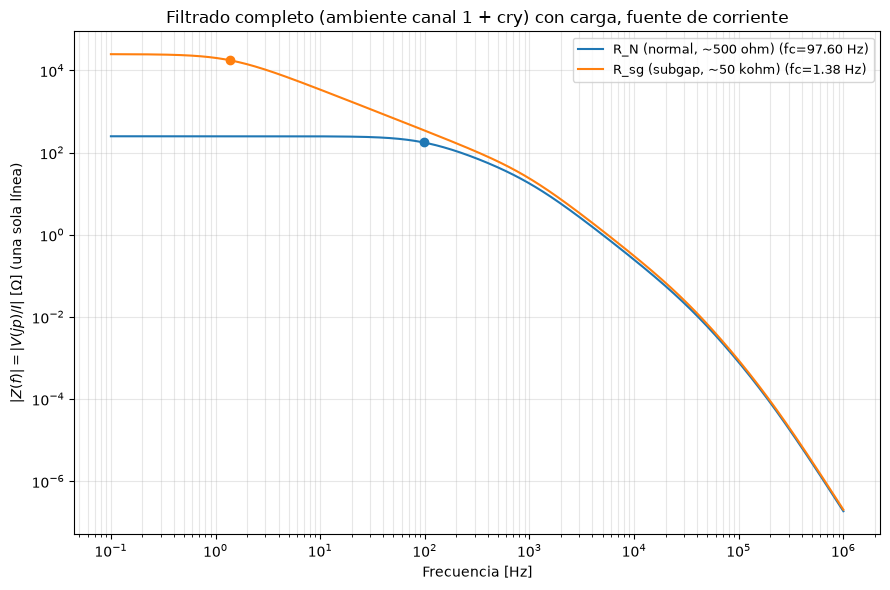

In [12]:
fila1 = resultados.iloc[0]
R_ta, C_ta = fila1.R_ta_ohm, fila1.C_ta_uF * 1e-6

fig, ax = plt.subplots(figsize=(9, 6))
for nombre, R_load in cargas.items():
    Zfun = lambda f, R_load=R_load: impedancia_completo_con_carga(f, R_ta, C_ta, 22.0, 47e-9, R_load, C_J)
    Z_vals = [abs(Zfun(f)) for f in frecuencias_z]
    fc = tabla_completo.loc[tabla_completo["canal"] == fila1.canal, nombre].iloc[0]
    z0 = abs(Zfun(1e-3))
    linea, = ax.loglog(frecuencias_z, Z_vals, label=f"{nombre} (fc={fc:.2f} Hz)")
    ax.scatter(fc, z0 / np.sqrt(2), color=linea.get_color(), zorder=5)

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel(r"$|Z(f)| = |V(jp)/I|$ [$\Omega$] (una sola línea)")
ax.set_title(f"Filtrado completo (ambiente canal {fila1.canal:.0f} + cry) con carga, fuente de corriente")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Cierre

Quedó armado, partiendo siempre del circuito real exportado de LTspice
(`-netlist`, nunca leído a ojo del esquemático):

1. **Cada filtro solo** (ambiente y criogénico por separado), fuente de
   tensión, circuito abierto — el baseline limpio. Ambiente: 6 canales
   contra la Tabla 5.1 (< 0,3%). Criogénico: contra la Figura 5.8 (0,42%).
2. **Cada filtro solo, con carga** ($R_N\|C_J$ o $R_{sg}\|C_J$), fuente
   de corriente.
3. **El filtrado completo** (ambiente + criogénico en cadena real,
   `2lineas_conRC.asc`), abierto y con carga.

En **todos los casos**, la medición es sobre **una sola línea**, antes de
la resistencia/carga y nunca entre sus dos bornes ni la diferencial
completa entre líneas.

**La pregunta de la tesis (¿por qué "no varía significativamente" la
$f_c$ del filtrado completo con la carga?) se resolvió**: el arreglo mide
a **4 puntas**, no a 2. La línea de **corriente** ($I^+/I^-$) sí depende
fuerte de la carga (verificado, es física real: los capacitores del
ambiente le dan a la corriente un camino de fuga más fácil que una carga
grande). Pero la línea de **tensión** ($V^+/V^-$, hacia el
nanovoltímetro) lleva corriente ~0, así que nunca ve ese efecto de carga
— su $f_c$ es, por construcción, la misma que la del circuito abierto,
sin importar $R_N$ o $R_{sg}$, y queda muy cerca de la del ambiente solo
(canal 1: 170,1 Hz vs 180,5 Hz, un 5% más restrictiva). Es la línea de
tensión la que Fran reporta como $f_c^t$, y por eso "no varía
significativamente".

(De paso, al armar esta comparación se encontró y corrigió un bug real
en `ganancia_completo_abierto_V`: le faltaba la primera resistencia de
cada línea del ambiente, válido de saltear con fuente de corriente pero
no con fuente de tensión — se detectó porque en el límite "criogénico sin
efecto" no reproducía los 180 Hz del ambiente solo.)

Quedan dos detalles menores sin cerrar (no críticos para esta
conclusión): no pude correr los `.asc` de LTspice en batch en esta
máquina para chequear contra un `.meas` real, y no confirmé si los
capacitores del ambiente comparten tierra entre las dos líneas de
corriente — pero el resultado de la línea de tensión no depende de esa
tierra en absoluto.